<a href="https://www.kaggle.com/code/richardhhong/fertilizers-eda?scriptVersionId=244090998" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Understanding the Outcome Variable

### What Each Fertilizer Type Means:

For all the fertilizers in the form "number-number-number", it refers to the percent of the fertilizer that is nitrogen, phosphorus, and potassium content respectively (e.g., 17-17-17 = 17% Nitrogen, 17% Phosphorus, and 17% Potassium). For any fertilizers in this form without a 3rd number, it refers to only having nitrogen and phosphorus in the fertilizer.

- **28-28:**&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;28% Nitrogen, 28% Phosphorus, 0% Potassium &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; — A fertilizer primarily for vegetative growth, often seen in early growth stages  
- **17-17-17:**&nbsp;&nbsp;&nbsp;17% Nitrogen, 17% Phosphorus, 17% Potassium &nbsp;&nbsp;&nbsp; — A balanced fertilizer  
- **10-26-26:**&nbsp;&nbsp;&nbsp;10% Nitrogen, 26% Phosphorus, 26% Potassium &nbsp;&nbsp;&nbsp; — Fertilizer for plants in flower or fruit producing stages  
- **20-20:**&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;20% Nitrogen, 20% Phosphorus &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; — Similar use to 28-28 but more dilute, used in place of 28-28 for more fertile soils or avoiding overfertilization  
- **14-35-14:**&nbsp;&nbsp;&nbsp;14% Nitrogen, 35% Phosphorus, 14% Potassium &nbsp;&nbsp;&nbsp; — For flower production and root growth  
- **DAP:**&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;18% Nitrogen, 46% Phosphorus &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; — For early stage fertilization  
- **Urea:**&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;46% Nitrogen &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; — Used for providing nitrogen in general to plants


## Actual Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mutual_info_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


import warnings
warnings.simplefilter("ignore")

In [2]:
df_test = pd.read_csv("/kaggle/input/playground-series-s5e6/test.csv")
df_train = pd.read_csv("/kaggle/input/playground-series-s5e6/train.csv")

In [3]:
df_train.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               750000 non-null  int64 
 1   Temparature      750000 non-null  int64 
 2   Humidity         750000 non-null  int64 
 3   Moisture         750000 non-null  int64 
 4   Soil Type        750000 non-null  object
 5   Crop Type        750000 non-null  object
 6   Nitrogen         750000 non-null  int64 
 7   Potassium        750000 non-null  int64 
 8   Phosphorous      750000 non-null  int64 
 9   Fertilizer Name  750000 non-null  object
dtypes: int64(7), object(3)
memory usage: 57.2+ MB


In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           250000 non-null  int64 
 1   Temparature  250000 non-null  int64 
 2   Humidity     250000 non-null  int64 
 3   Moisture     250000 non-null  int64 
 4   Soil Type    250000 non-null  object
 5   Crop Type    250000 non-null  object
 6   Nitrogen     250000 non-null  int64 
 7   Potassium    250000 non-null  int64 
 8   Phosphorous  250000 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 17.2+ MB


In [6]:
df_train.isna().sum()

id                 0
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

In [7]:
print(f"Unique Soil types in train: {sorted(df_train['Soil Type'].unique())}")
print(f"Unique Soil types in test: {sorted(df_test['Soil Type'].unique())}")

Unique Soil types in train: ['Black', 'Clayey', 'Loamy', 'Red', 'Sandy']
Unique Soil types in test: ['Black', 'Clayey', 'Loamy', 'Red', 'Sandy']


In [8]:
print(f"Unique Crop types in train: {sorted(df_train['Crop Type'].unique())}")
print(f"Unique Crop types in test: {sorted(df_test['Crop Type'].unique())}")

Unique Crop types in train: ['Barley', 'Cotton', 'Ground Nuts', 'Maize', 'Millets', 'Oil seeds', 'Paddy', 'Pulses', 'Sugarcane', 'Tobacco', 'Wheat']
Unique Crop types in test: ['Barley', 'Cotton', 'Ground Nuts', 'Maize', 'Millets', 'Oil seeds', 'Paddy', 'Pulses', 'Sugarcane', 'Tobacco', 'Wheat']


In [9]:
print(f"Unique Fertilizers: {df_train['Fertilizer Name'].unique()}")

Unique Fertilizers: ['28-28' '17-17-17' '10-26-26' 'DAP' '20-20' '14-35-14' 'Urea']


In [10]:
df_train.describe()

,id,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,31.503565,61.038912,45.184147,23.093808,9.478296,21.073227
std,216506.495284,4.025574,6.647695,11.794594,11.216125,5.765622,12.346831
min,0.000000,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,187499.750000,28.000000,55.000000,35.000000,13.000000,4.000000,10.000000
50%,374999.500000,32.000000,61.000000,45.000000,23.000000,9.000000,21.000000
75%,562499.250000,35.000000,67.000000,55.000000,33.000000,14.000000,32.000000
max,749999.000000,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000


In [11]:
df_test.describe()

,id,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000
mean,874999.500000,31.491648,61.045120,45.190444,23.139612,9.487764,21.12206
std,72168.927986,4.024093,6.636372,11.793167,11.215956,5.766860,12.38087
min,750000.000000,25.000000,50.000000,25.000000,4.000000,0.000000,0.00000
25%,812499.750000,28.000000,55.000000,35.000000,13.000000,4.000000,10.00000
50%,874999.500000,31.000000,61.000000,45.000000,23.000000,10.000000,21.00000
75%,937499.250000,35.000000,67.000000,55.000000,33.000000,14.000000,32.00000
max,999999.000000,38.000000,72.000000,65.000000,42.000000,19.000000,42.00000


In [12]:
numerical_features = list(df_train.select_dtypes(include=['int64']).columns)
numerical_features.remove('id')
categorical_features = list(df_test.select_dtypes(include=['object']).columns)
outcome = ['Fertilizer Name']

### Distribution of Outcome

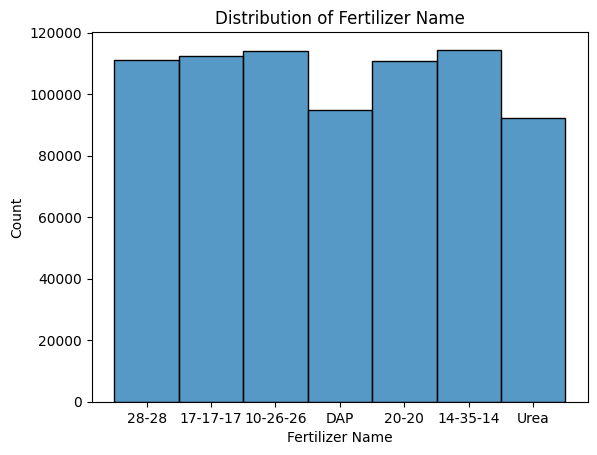

In [13]:
sns.histplot(df_train['Fertilizer Name'])
plt.title('Distribution of Fertilizer Name')
plt.show()

## Numerical Features

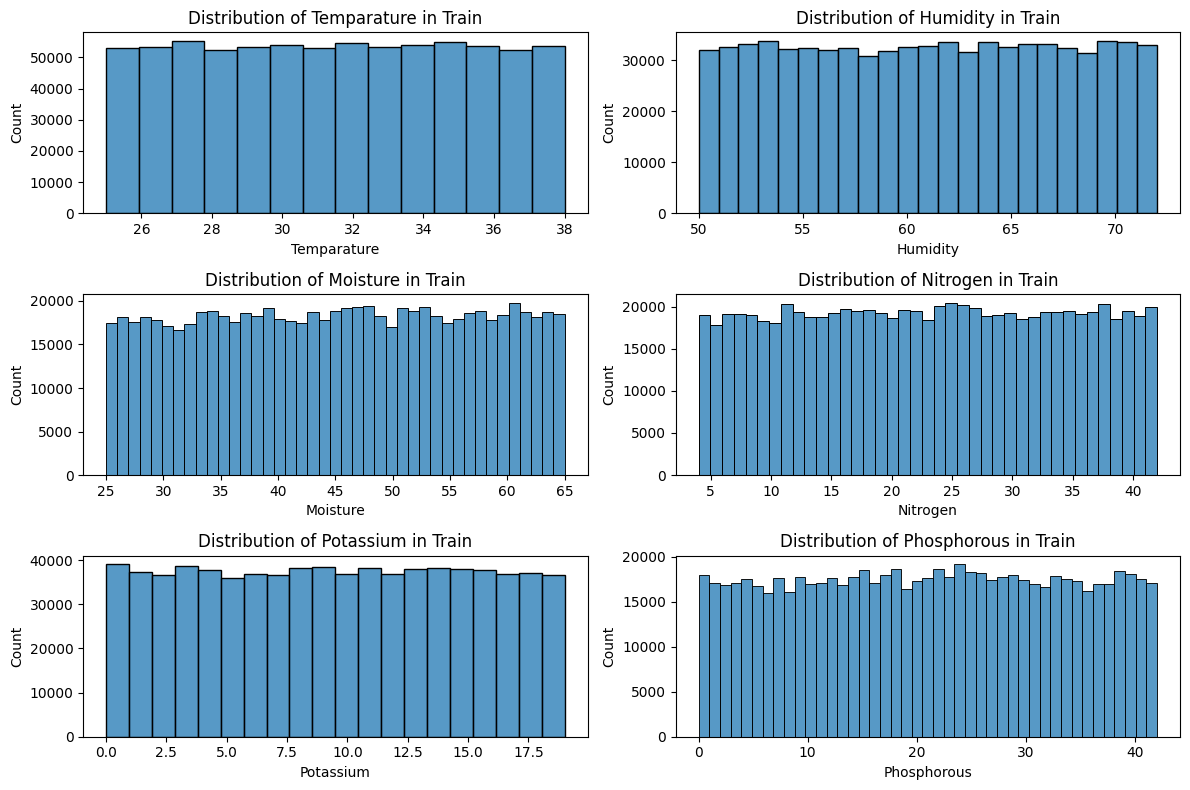

In [14]:
# distributions of numerical features in df_train
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df_train[feature], ax=axes[i], bins=df_train[feature].nunique())
    axes[i].set_title(f'Distribution of {feature} in Train')

plt.tight_layout()
plt.show()

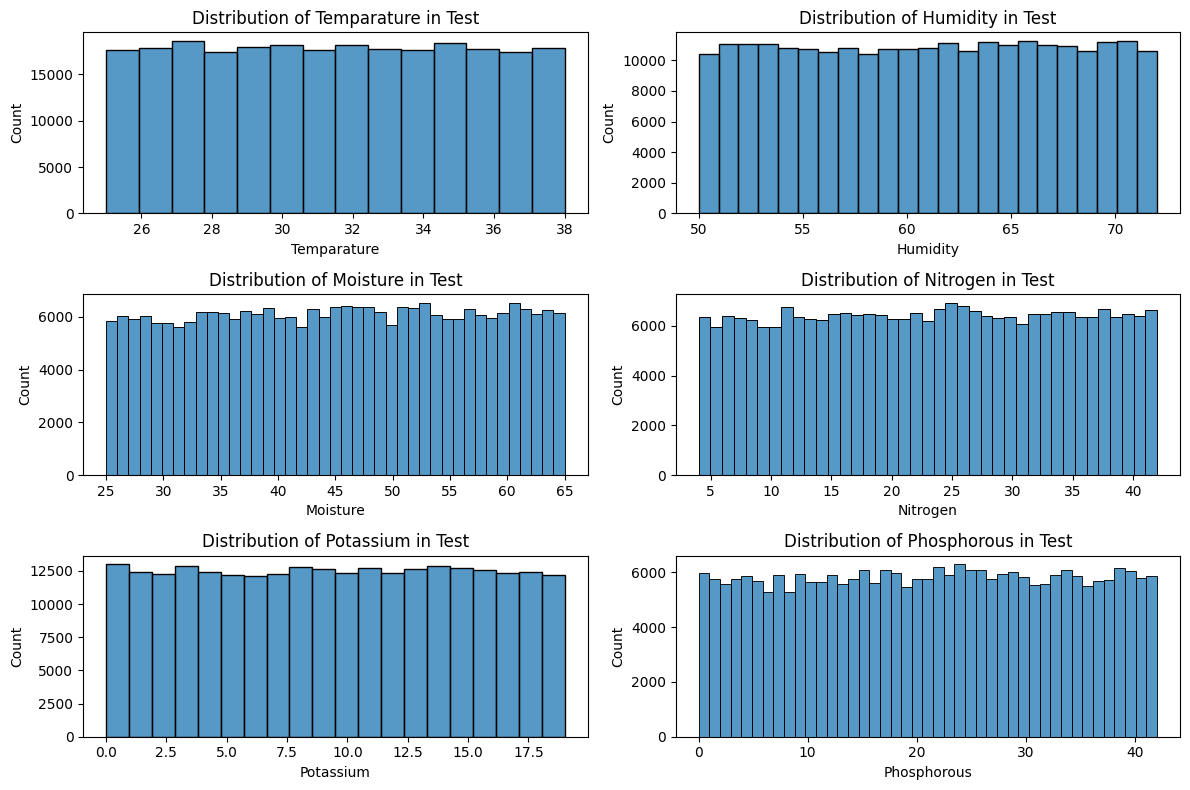

In [15]:
# distributions of numerical features in df_test
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df_test[feature], ax=axes[i], bins=df_test[feature].nunique())
    axes[i].set_title(f'Distribution of {feature} in Test')

plt.tight_layout()
plt.show()

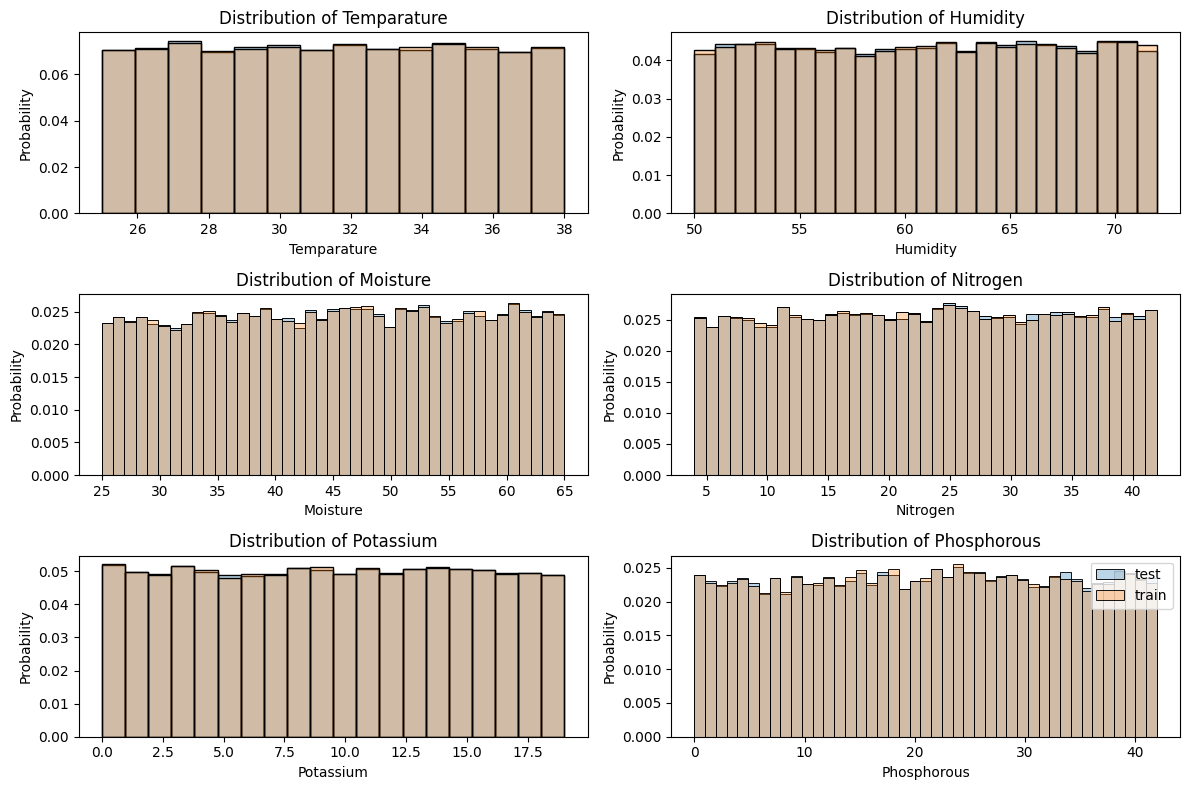

In [16]:
# Comparing distributions of numerical features in train and test
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df_test[feature], ax=axes[i], alpha=0.3, fill=True, 
                 bins=min(df_test[feature].nunique(), 43), stat='probability', label='test')
    sns.histplot(df_train[feature], ax=axes[i], alpha=0.3, fill=True, 
                 bins=min(df_train[feature].nunique(), 43), stat='probability', label='train')
    axes[i].set_title(f'Distribution of {feature}')

plt.legend()
plt.tight_layout()
plt.show()

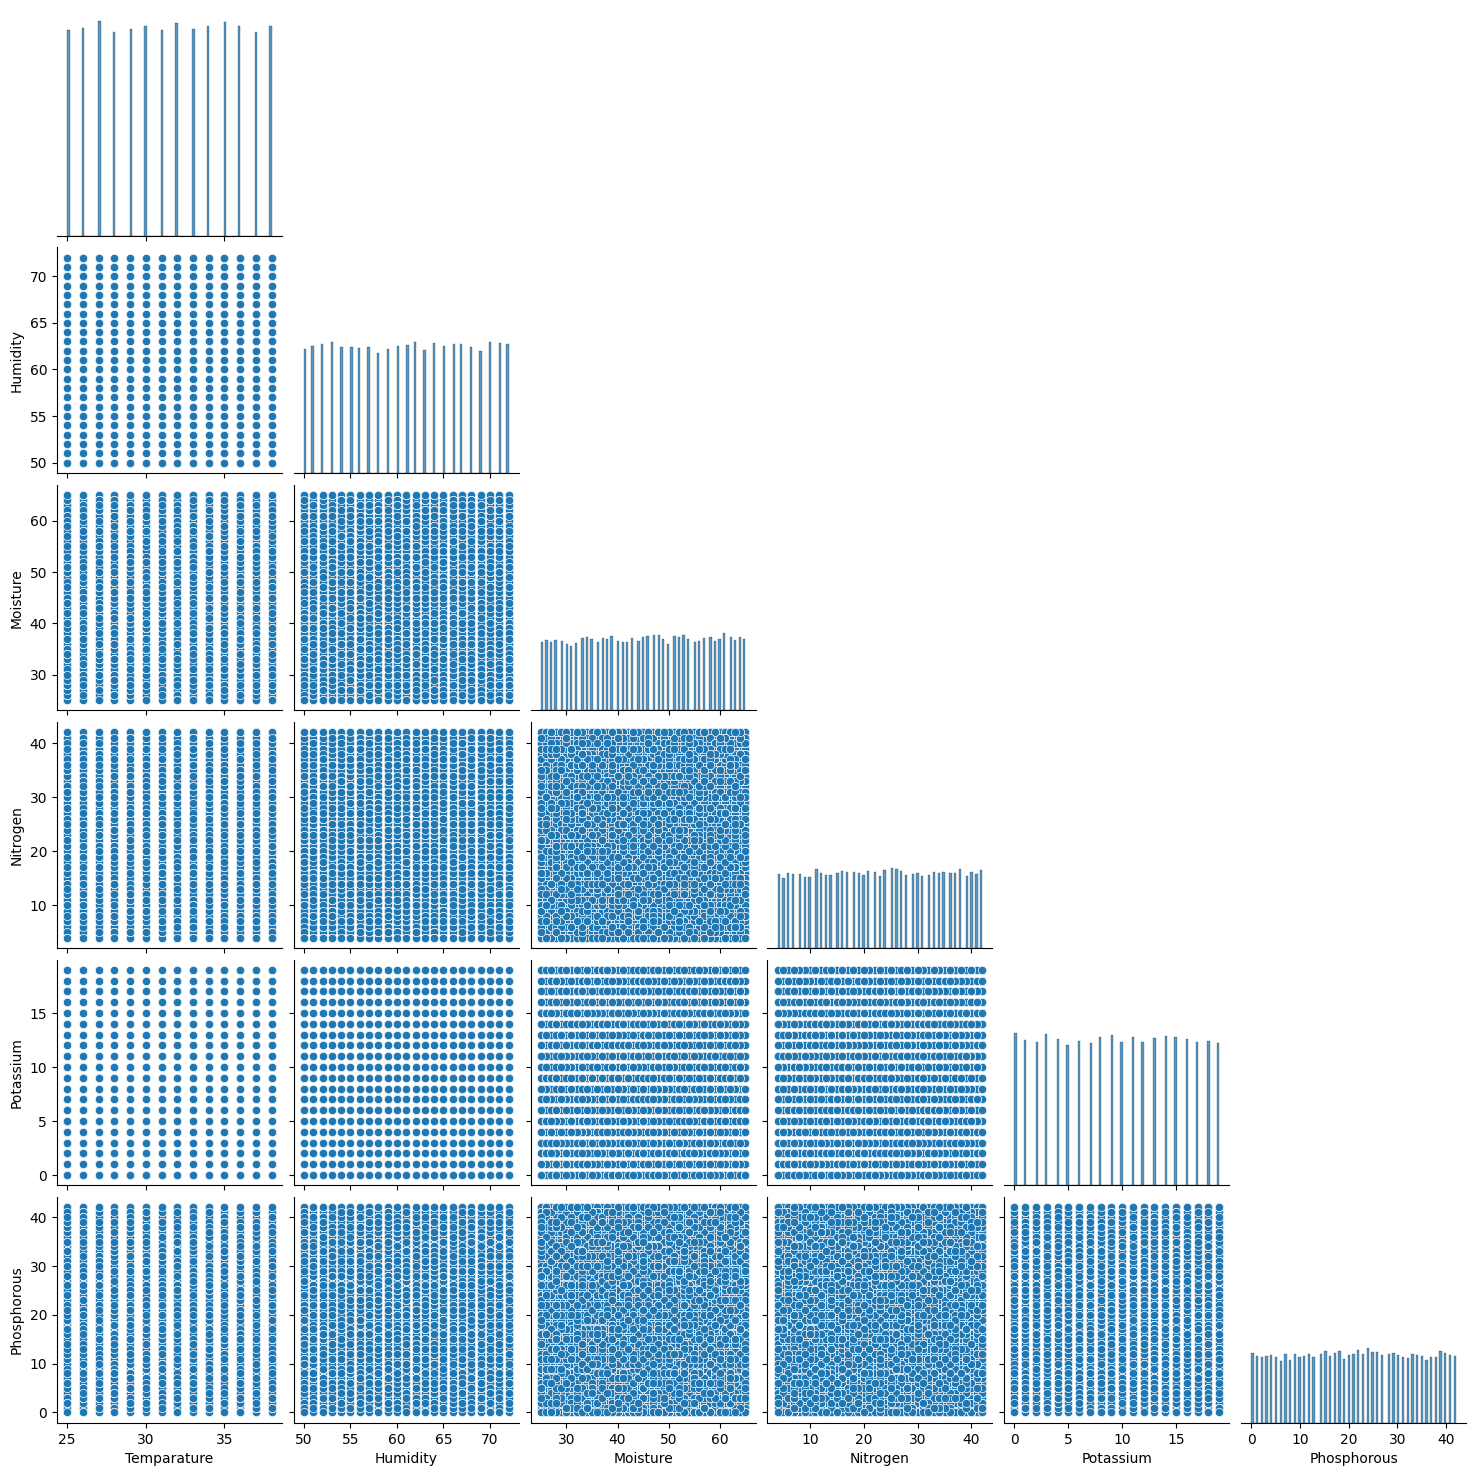

In [17]:
# Scatterplots
sns.pairplot(data=df_train, vars=numerical_features, corner=True)
plt.show()

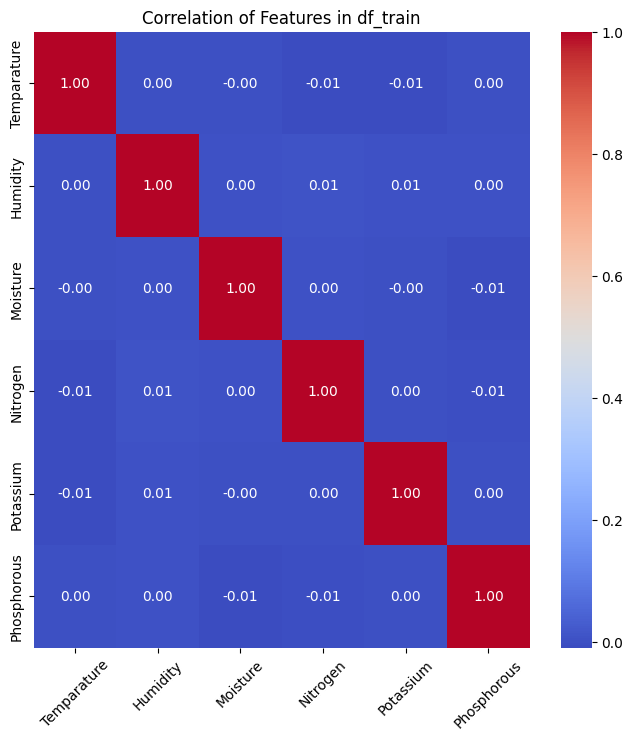

In [18]:
# Correlation Matrix
corr_matrix = df_train[numerical_features].corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.xticks(rotation=45)
plt.title('Correlation of Features in df_train')
plt.show()

In [19]:
# variance inflation factors
X = df_train[numerical_features].copy()
X_vif = add_constant(X)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})

vif_data = vif_data[vif_data['Feature'] != 'const']

print(vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True))

       Feature       VIF
0  Temparature  1.000141
1    Potassium  1.000130
2     Nitrogen  1.000118
3     Humidity  1.000091
4  Phosphorous  1.000081
5     Moisture  1.000072


## Categorical Features

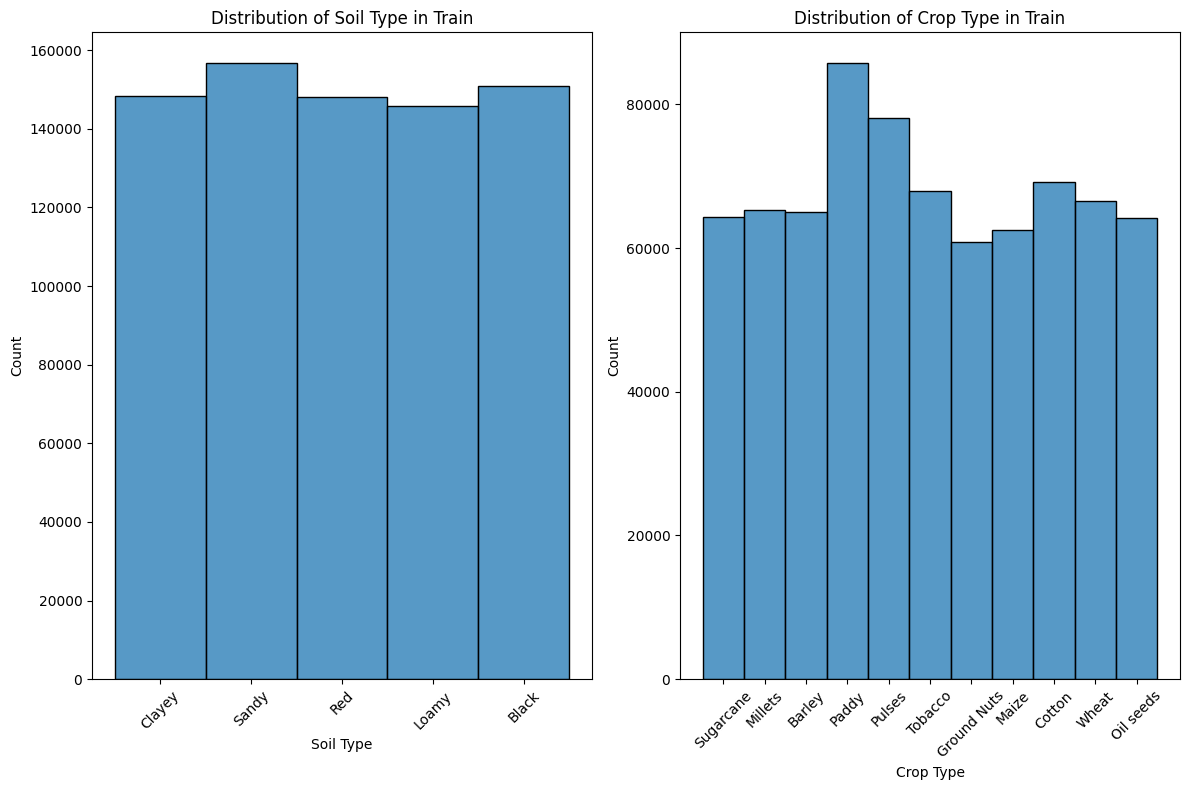

In [20]:
# distributions of categorical features in training data
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.histplot(df_train[feature], ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} in Train')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

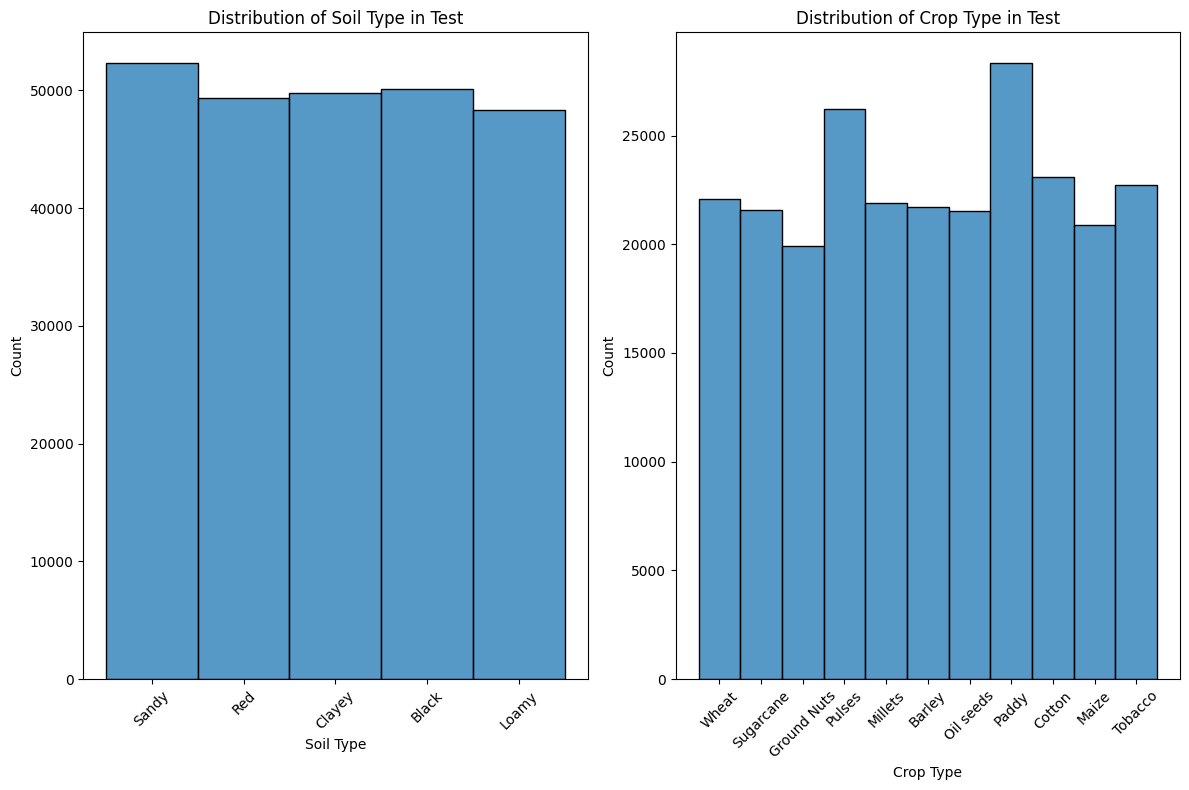

In [21]:
# distributions of categorical features in test data
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.histplot(df_test[feature], ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} in Test')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

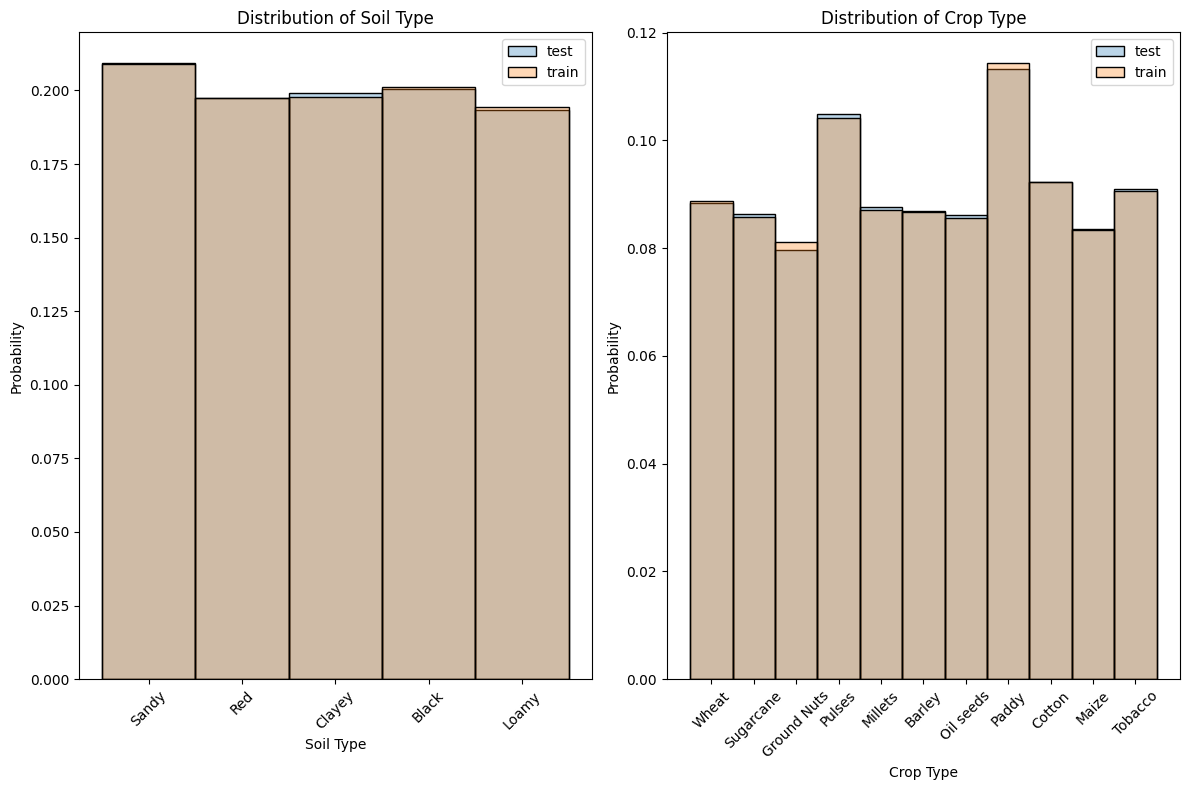

In [22]:
# distributions of categorical features in test data
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.histplot(df_test[feature], ax=axes[i], label='test', alpha=0.3, fill=True, stat='probability')
    sns.histplot(df_train[feature], ax=axes[i], label='train', alpha=0.3, fill=True, stat='probability')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].legend()

plt.tight_layout()
plt.show()

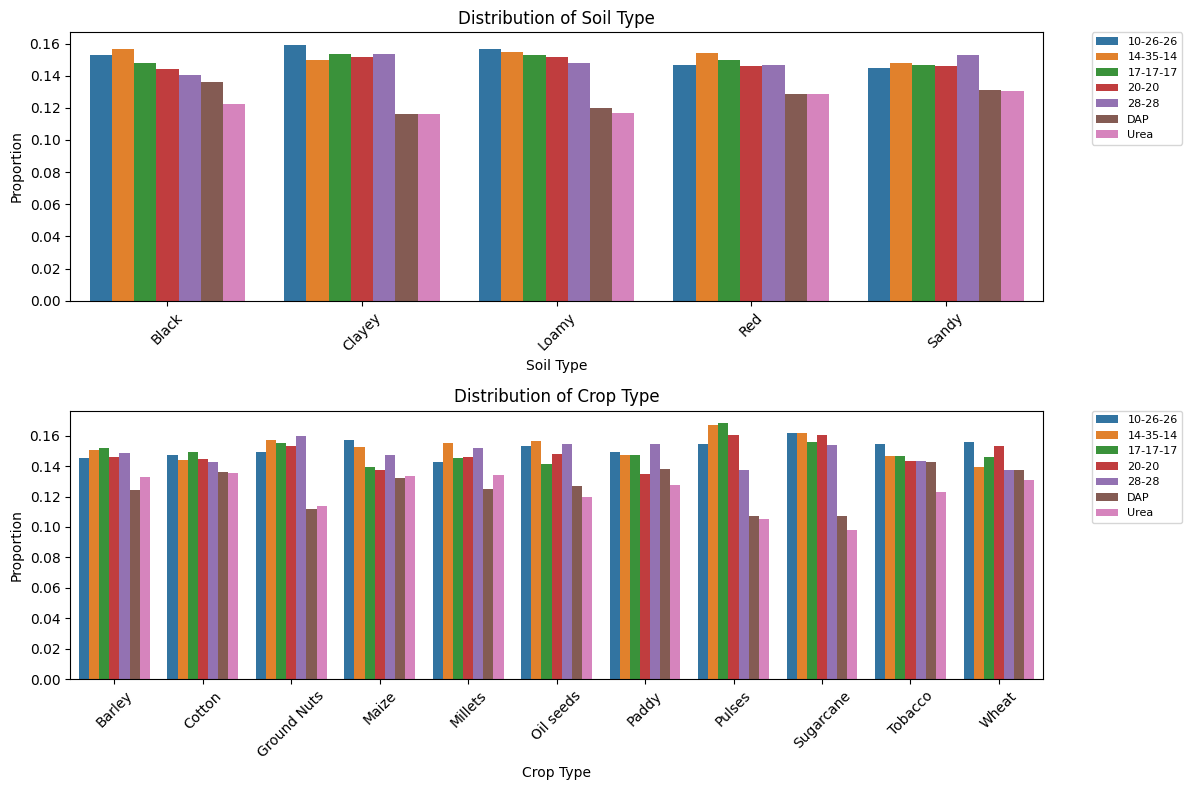

In [23]:
# distributions of categorical features in training data
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    counts = df_train.groupby([feature, 'Fertilizer Name']).size().rename('Count')
    total = counts.groupby(level=0).transform('sum')
    prop_df = (counts / total).reset_index(name='Proportion')

    sns.barplot(data=prop_df, x=feature, y='Proportion', hue='Fertilizer Name', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0., prop={'size': 8})

plt.tight_layout()
plt.show()

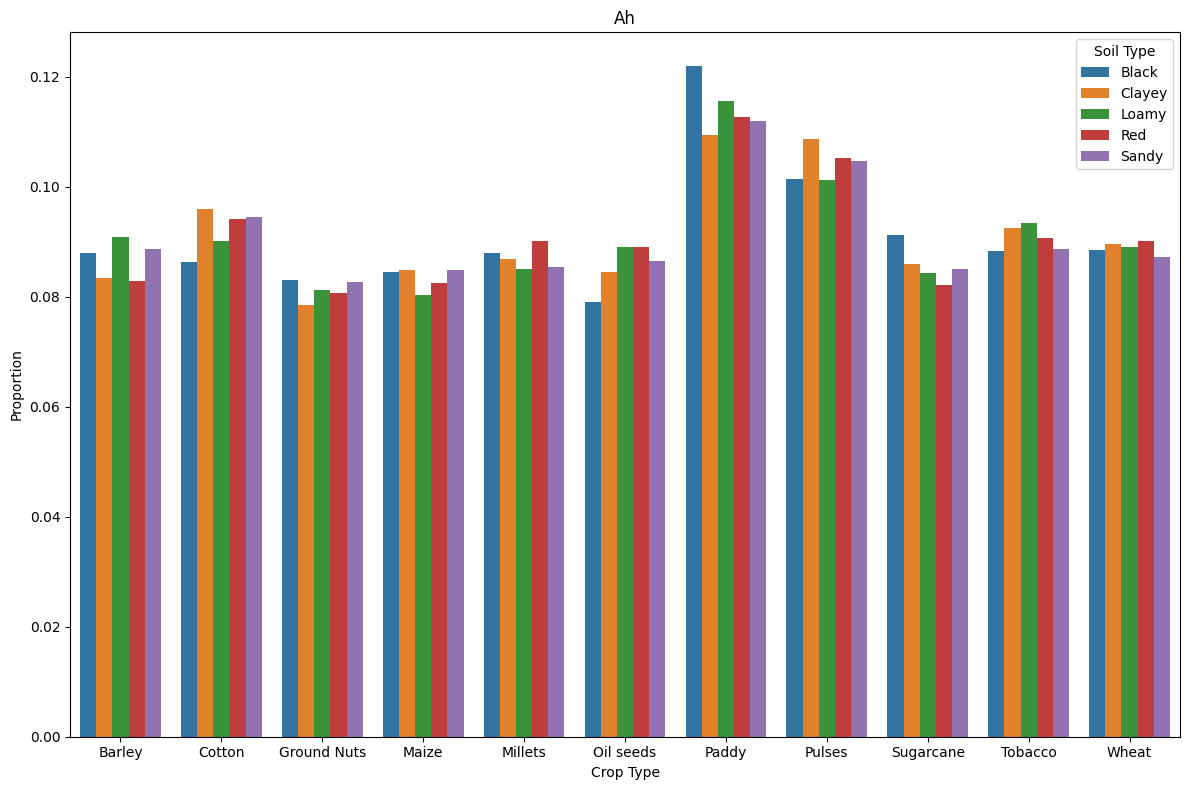

In [24]:
# soil type and crop type
plt.figure(figsize=(12, 8))

counts = df_train.groupby(['Soil Type', 'Crop Type']).size().rename('Count')
total = counts.groupby(level=0).transform('sum')
prop_df = (counts / total).reset_index(name='Proportion')

sns.barplot(data=prop_df, x='Crop Type', y='Proportion', hue='Soil Type')
plt.title('Ah')
# axes[i].tick_params(axis='x', rotation=45)
# axes[i].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0., prop={'size': 8})

plt.tight_layout()
plt.show()

## Relationships between Numeric and Categorical Features

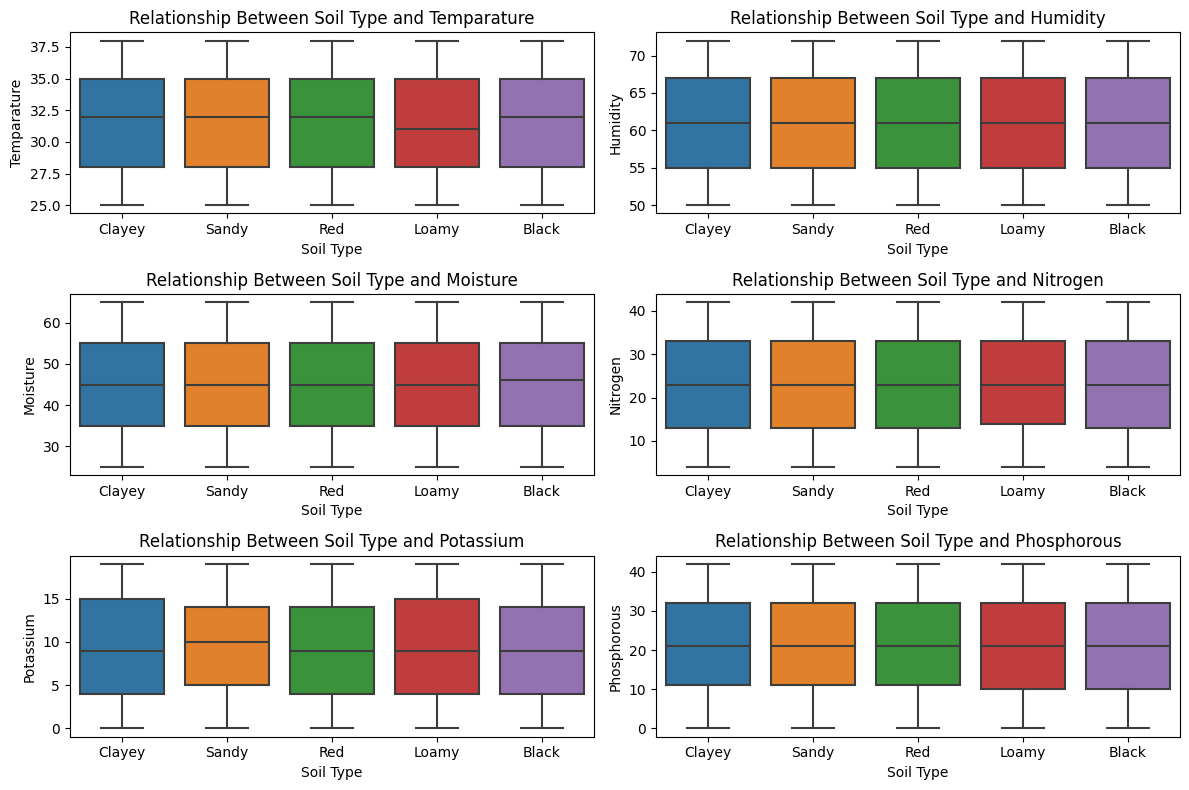

In [25]:
# Relationship between All Numeric and Soiltype
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df_train['Soil Type'], y=df_train[feature], ax=axes[i])
    axes[i].set_title(f'Relationship Between Soil Type and {feature}')

plt.tight_layout()
plt.show()

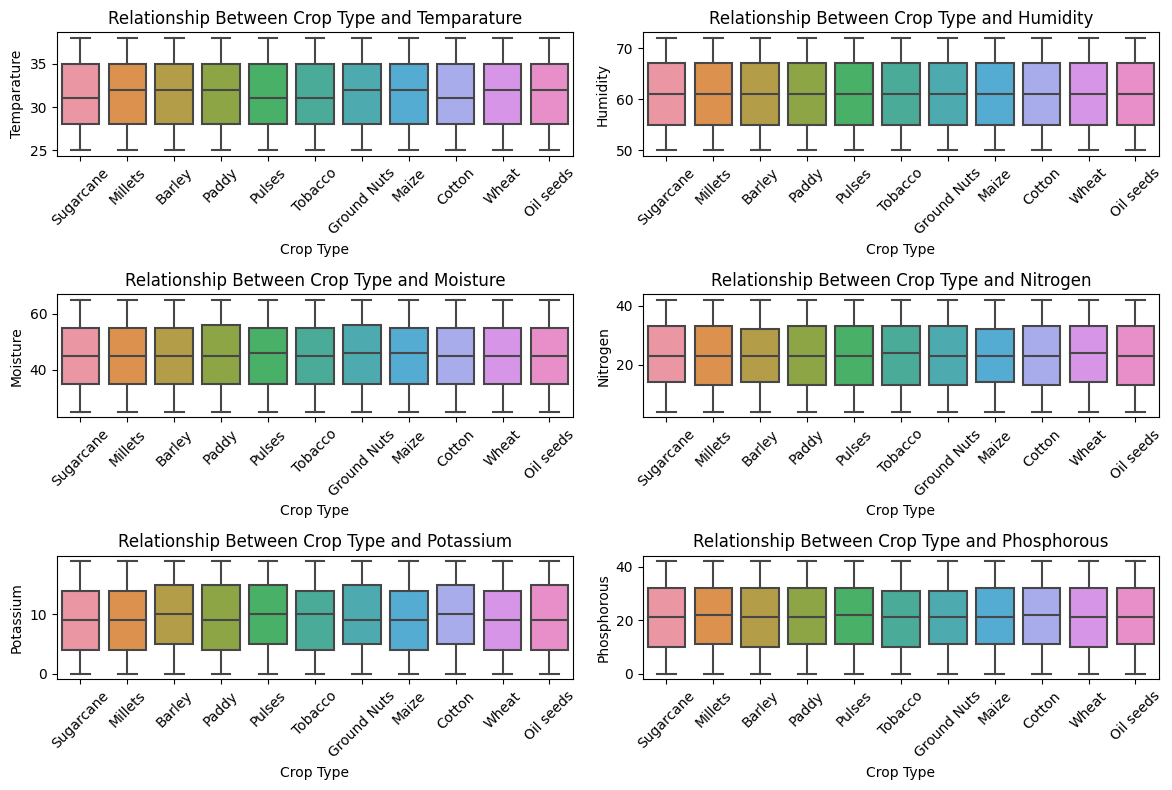

In [26]:
# Relationship between All Numeric and Crop Type
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df_train['Crop Type'], y=df_train[feature], ax=axes[i])
    axes[i].set_title(f'Relationship Between Crop Type and {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Miscellaneous Relationships

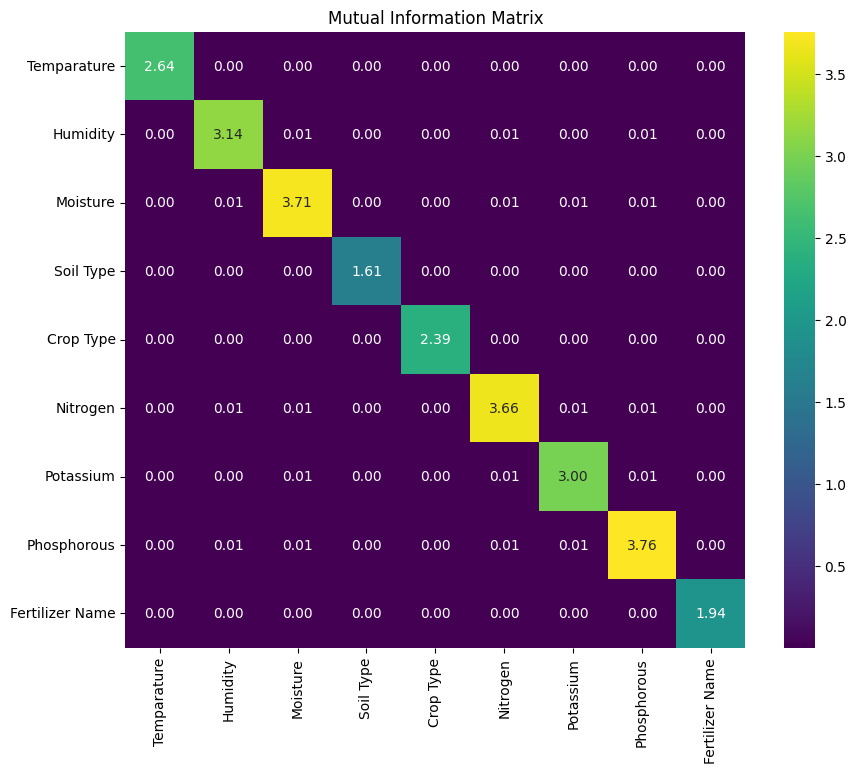

In [27]:
# Mutual information
all_columns = df_train.drop(columns=['id']).columns
mi_matrix = pd.DataFrame(index=all_columns, columns=all_columns, dtype=float)

for i in all_columns:
    for j in all_columns:
        mi_matrix.loc[i, j] = mutual_info_score(df_train[i], df_train[j])

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(mi_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis")
plt.title("Mutual Information Matrix")
plt.show()

## New Features

This set of features from: https://www.kaggle.com/code/omidbaghchehsaraei/single-xgboost-cv-0-36334-feature-engineering

In [28]:
original_numerical_cols = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']

def make_feature_set1(df):
    df_copy = df.copy() 
    df_copy['Temp_Humidity_Interaction'] = df_copy['Temparature'] * df_copy['Humidity']
    df_copy['N_P_Ratio'] = df_copy['Nitrogen'] / (df_copy['Phosphorous'].replace(0, 1))
    df_copy['K_P_Ratio'] = df_copy['Potassium'] / (df_copy['Phosphorous'].replace(0, 1))
    df_copy['Soil_Crop_Combination'] = df_copy['Soil Type'].astype(str) + '_' + df_copy['Crop Type'].astype(str)

    # Binning numerical features (as strings for categorical handling)
    for col in original_numerical_cols:
        df_copy[f'{col}_Binned'] = df_copy[col].astype(str)

    return df_copy

df_feature_set1 = make_feature_set1(df_train)

In [29]:
fs1 = ['Temp_Humidity_Interaction', 'N_P_Ratio', 'K_P_Ratio', 'Soil_Crop_Combination']
fs1_num = ['Temp_Humidity_Interaction', 'N_P_Ratio', 'K_P_Ratio']
fs1_cat = ['Soil_Crop_Combination']

In [30]:
df_feature_set1[fs1].describe()

,Temp_Humidity_Interaction,N_P_Ratio,K_P_Ratio
count,750000.000000,750000.000000,750000.000000
mean,1922.990404,2.850934,1.167071
std,324.355914,5.672695,2.482606
min,1250.000000,0.095238,0.000000
25%,1682.000000,0.619048,0.212121
50%,1900.000000,1.096774,0.451613
75%,2145.000000,2.222222,0.904762
max,2736.000000,42.000000,19.000000


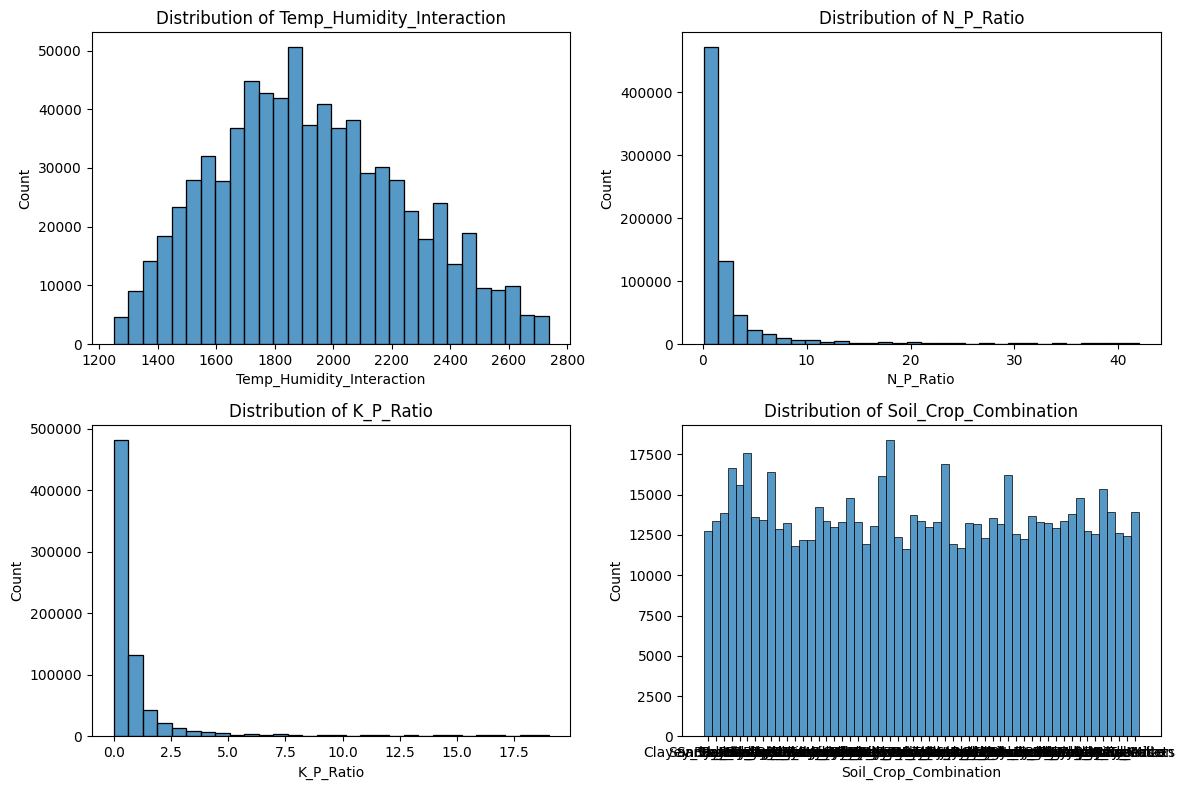

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(fs1):
    sns.histplot(df_feature_set1[feature], ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

In [32]:
df_feature_set1['Soil_Crop_Combination'].nunique()

55

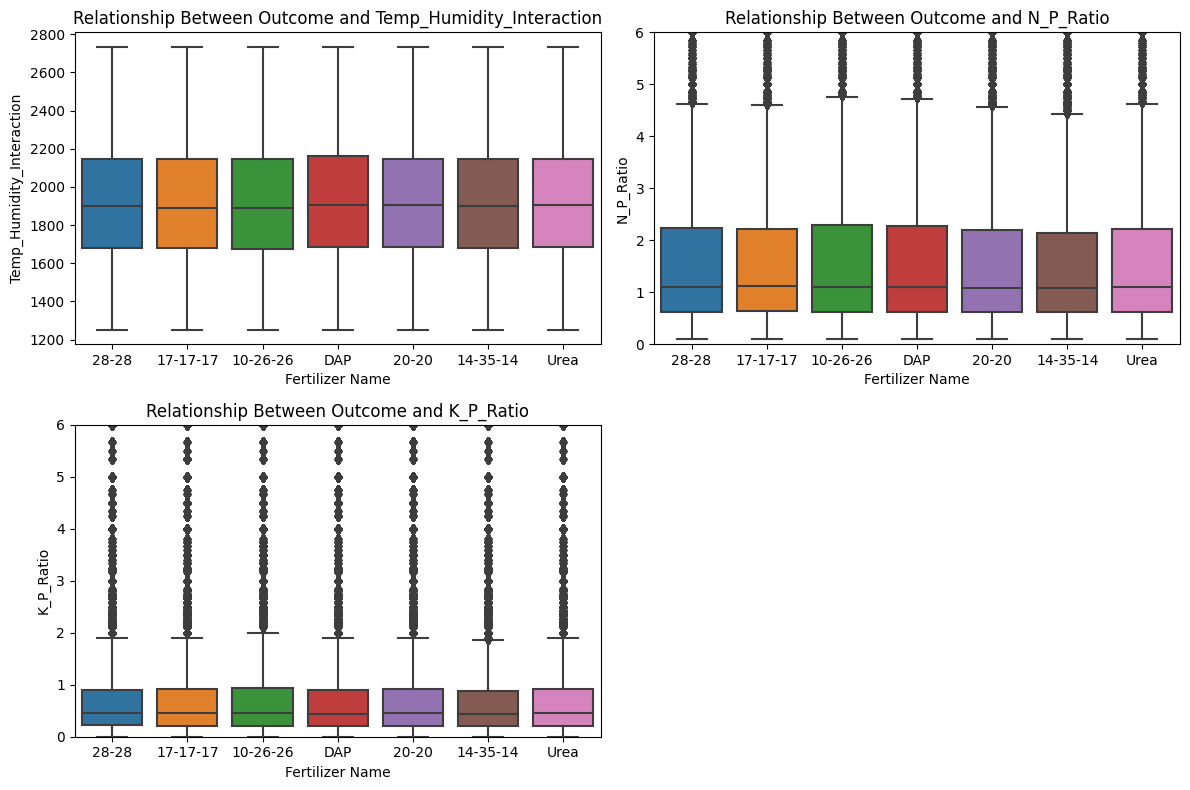

In [33]:
# relationship between new features and outcome
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(fs1_num):
    sns.boxplot(df_feature_set1, x='Fertilizer Name', y=feature, ax=axes[i])
    if i != 0:
        axes[i].set_ylim(0, 6)
    axes[i].set_title(f'Relationship Between Outcome and {feature}')

axes[3].remove()
plt.tight_layout()
plt.show()

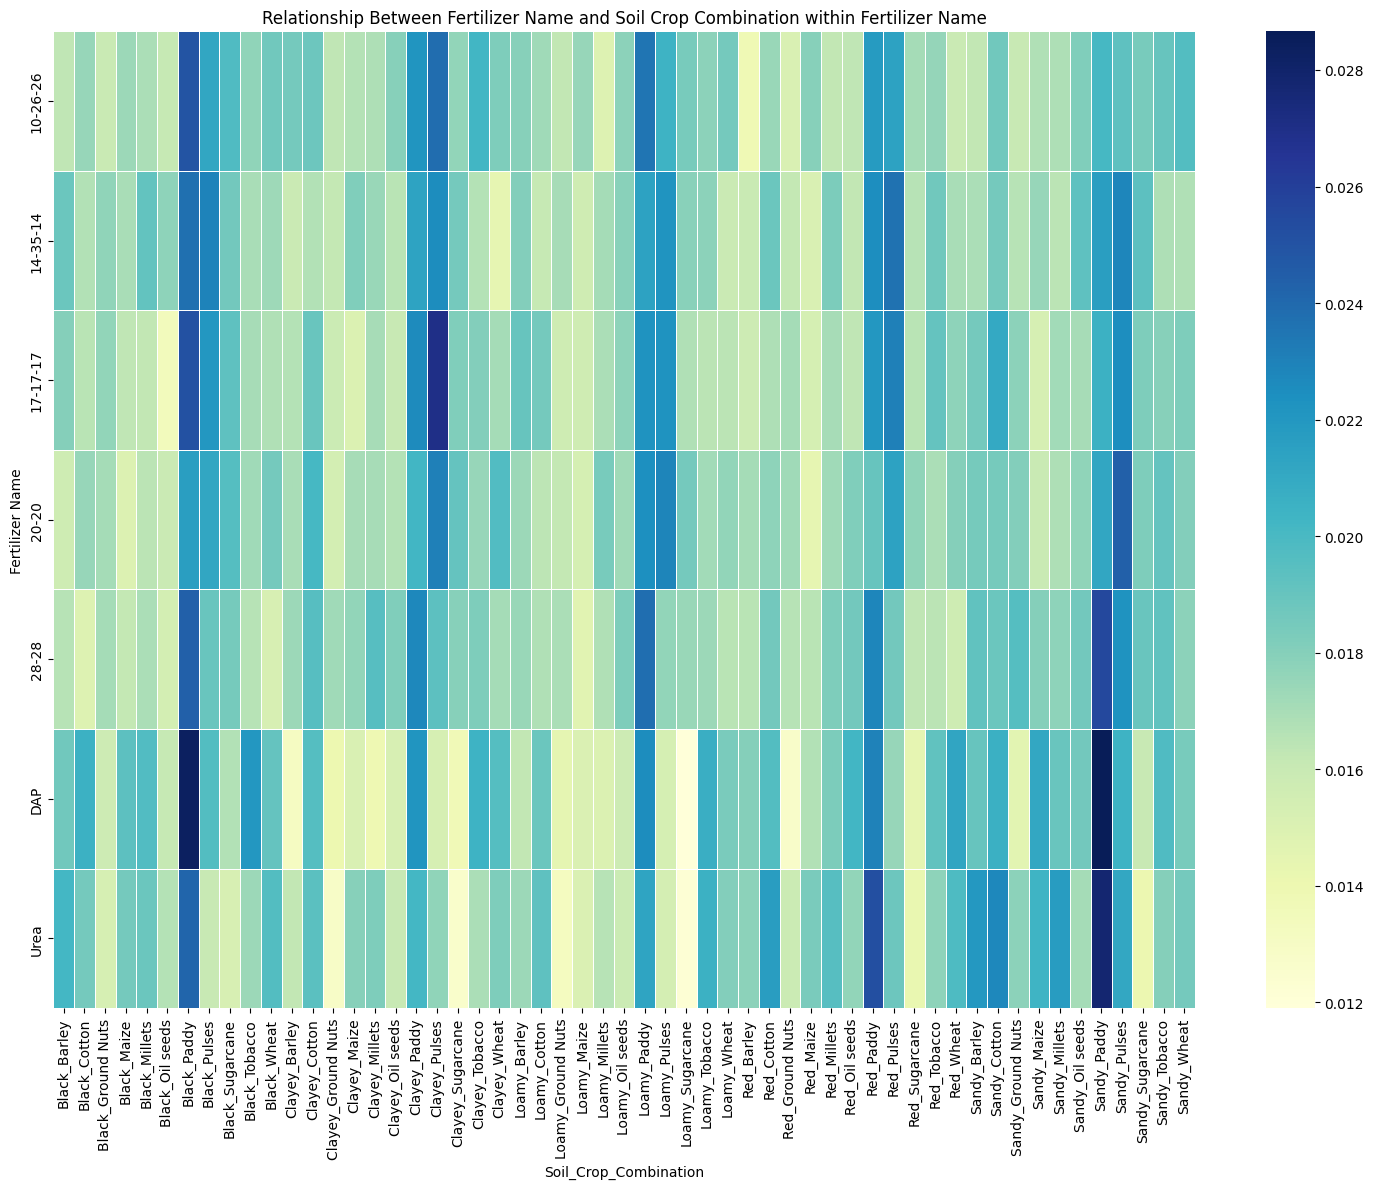

In [34]:
# relationship between outcome and Soil Crop Combination within Fertilizer Name
ct = pd.crosstab(df_feature_set1['Fertilizer Name'], df_feature_set1['Soil_Crop_Combination'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

plt.figure(figsize=(15, 12))
sns.heatmap(ct_norm, cmap="YlGnBu", linewidths=0.5)
plt.title("Relationship Between Fertilizer Name and Soil Crop Combination within Fertilizer Name")
plt.xlabel("Soil_Crop_Combination")
plt.ylabel("Fertilizer Name")
plt.tight_layout()
plt.show()

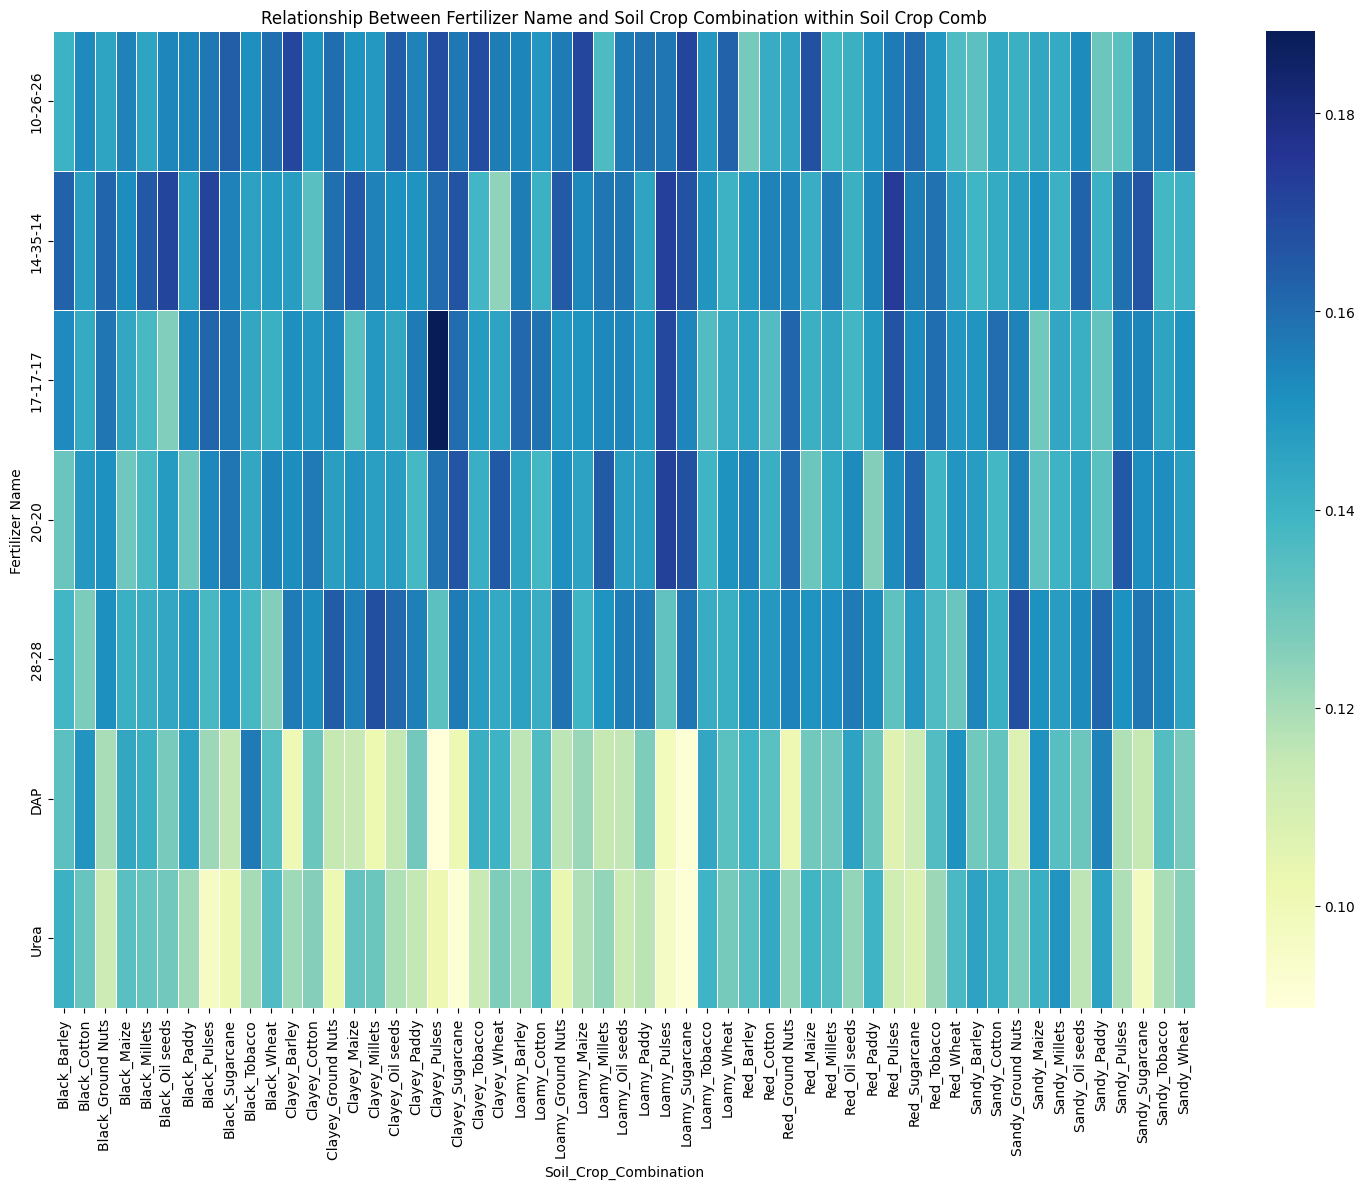

In [35]:
# relationship between outcome and Soil Crop Combination within Soil Crop Combination
ct = pd.crosstab(df_feature_set1['Fertilizer Name'], df_feature_set1['Soil_Crop_Combination'])
ct_norm = ct.div(ct.sum(axis=0), axis=1)

plt.figure(figsize=(15, 12))
sns.heatmap(ct_norm, cmap="YlGnBu", linewidths=0.5)
plt.title("Relationship Between Fertilizer Name and Soil Crop Combination within Soil Crop Comb")
plt.xlabel("Soil_Crop_Combination")
plt.ylabel("Fertilizer Name")
plt.tight_layout()
plt.show()